# 14 Node Test Grid

In [1]:
using LightGraphs
using DifferentialEquations
using Statistics
using Random
using LinearAlgebra
using StatsPlots
using StatsBase
using GraphRecipes
using Distributions
using DelimitedFiles

In [2]:
#Generate G matrix given noise covariance matrix C
function G_generate(C)
    U, Σ, V = svd(C)
    U*diagm(0 => sqrt.(Σ))*U'
end

G_generate (generic function with 1 method)

In [3]:
function stochControlPIDead(grid,P,B,M,D,u0,tf,C,α,αL,β,σ,db,nodelist,tp)
    n = nv(grid)
    E = incidence_matrix(grid;oriented=true)
    G=σ*G_generate(C)
    print(G)

    function f(du,u,p,t)
     
        listy=zeros(n)
        for i in 1:n
            if abs(u[Int(i+n)])>db
                listy[i]=1
            end
        end
        
        δi    = u[1:n]
        δidot = u[n+1:2n]
        du[1:n]=δidot 
        p=u[3n+1:end] #p is noise in power term
        du[3n+1:end]=(-1/tp)*p
        
        y = u[2n+1:3n]
        du[2n+1:3n] = δidot
        sign1=sign.(δidot)
        du[n+1:2n] = (-D.*δidot .- E*(B.*sin.(E'*δi)) .+ P .+ p .- αL*δidot .-
        (α*δidot .- α*db*sign1 .+ αL*db*sign1 .- αL*δidot).*listy.*nodelist .- β*y.*listy.*nodelist)./M 
        
#         for i in 1:n
#             if sign1[i]==1
#                 du[n+i] = (-D[i]*δidot[i] - (E*(B.*sin.(E'*δi)))[i] + P[i] + p[i] - α*(δidot[i] - db)*listy[i] - 
#                     αL*db*nodelist[i]*listy[i] - β*y[i]*nodelist[i]*listy[i] - αL*δidot[i]*(1-listy[i]))/M[i]
#             elseif sign1[i] == -1
#                 du[n+i] = (-D[i]*δidot[i] - (E*(B.*sin.(E'*δi)))[i] + P[i] + p[i] - α*(δidot[i] + db)*listy[i]
#                     + αL*db*nodelist[i]*listy[i] - β*y[i]*nodelist[i]*listy[i] - αL*δidot[i]*(1-listy[i]))/M[i]
#             else
#                 du[n+i] = (-D[i]*δidot[i] - (E*(B.*sin.(E'*δi)))[i] + P[i] + p[i])/M[i]
#             end
#         end
    end
    
    function g(du,u,p,t)
        
        A=zeros(4n,4n)
        for i in 1:n
            A[3n+i,3n+1:4n]=G[i,1:n]
        end
        du.=A
        
    end
    
    #Market jump noise
    markettimes = [15*i for i in 1:fld(tf,15)]
    condition(u,t,integrator) = t ∈ markettimes
    affect!(integrator)=integrator.u[3n+1:end] .+= rand(Normal(0.0,0.0),n) #.+ rand(Normal(-0.05,0.02))
    cb = DiscreteCallback(condition,affect!,save_positions=(false,false))
    
    prob=SDEProblem(f,g,u0,(0.0,tf),noise_rate_prototype=zeros(4n,4n))
    sol=solve(prob,LambaEM(),tstops=markettimes,saveat=1/60,maxiters=1e10)
    
    return sol
end

stochControlPIDead (generic function with 1 method)

In [4]:
Bus=readdlm("Bus.txt");
Edge=readdlm("Edge.txt");

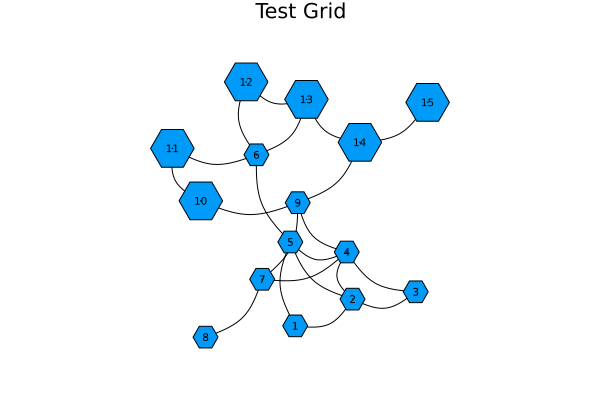

In [5]:
testg = SimpleGraph(14)
for i in 1:length(Edge[1:end,1])
    add_edge!(testg,Int(Edge[i,1]),Int(Edge[i,2]))
end
add_vertex!(testg)

#Adding 15th node to balance power in network
add_edge!(testg,14,15)
graphplot(testg,names=1:nv(testg),nodesize=0.35,title="Test Grid")

[0.5 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.5 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.5 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.5 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.5 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.5 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0 0.5 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.5 0.0 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.5 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.5 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.5 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.5 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.5 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.5 0.0; 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.5]

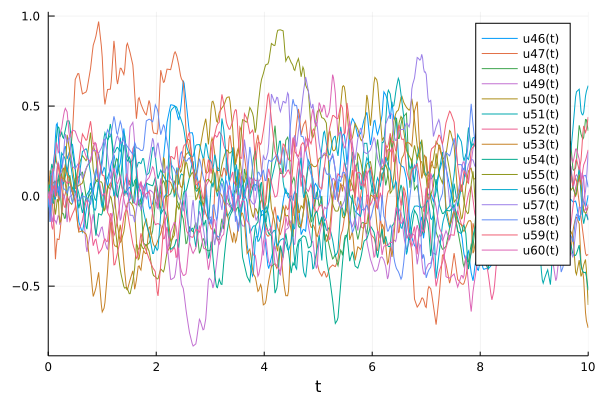

In [6]:
tf=10.0
g=testg
α=12.5 #
αL=1.5 #System droop
σ=0.5 
β=0.005 #Integral control term
tp=0.5 #Time-correlated time scale in minutes
nodelist=ones(nv(g))
db=0.015 #Frequency deadband (in Hz)

#Random.seed!(120);

C=zeros(nv(g),nv(g))
C[diagind(C)].=1

M = vcat((6)*ones(nv(g))) #Vector of nodal inertia values
D = vcat(0.01*ones(nv(g))) #Vector of nodal damping terms
B = vcat(Edge[1:end,8]./(Edge[1:end,7].^2 .+ Edge[1:end,8].^2),1.0) #Vector of susceptances ordered by edge index (e1,e2,...)

#Adding a 15th node to balance power
Pi=Bus[1:end,12].-Bus[1:end,10]
P = vcat(Pi,-sum(Pi))

u0=zeros(4*nv(g))

varslist=[(0,i) for i in (3*nv(g)+1:4*nv(g))] #(0,i) means plot variable i against time
    
sol=stochControlPIDead(g,P,B,M,D,u0,tf,C,α,αL,β,σ,db,nodelist,tp);    

plot(sol,vars=varslist)

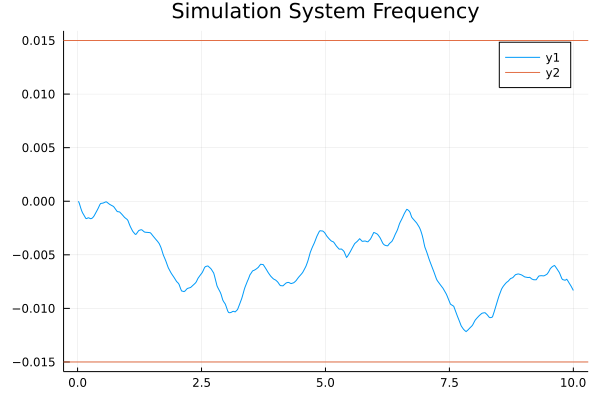

In [7]:
#Calculating system frequency over time

n=nv(g)
tlength=Int(length(sol[1,1:end]))

avgfreq=[mean(sol[n+1:2*n,i]) for i in 1:tlength]

t=LinRange(1,Int(60*tf),Int(60*tf+1))
p2=plot(t/60,avgfreq[1:end],title="Simulation System Frequency")
hline!(p2,[0.015,-0.015])

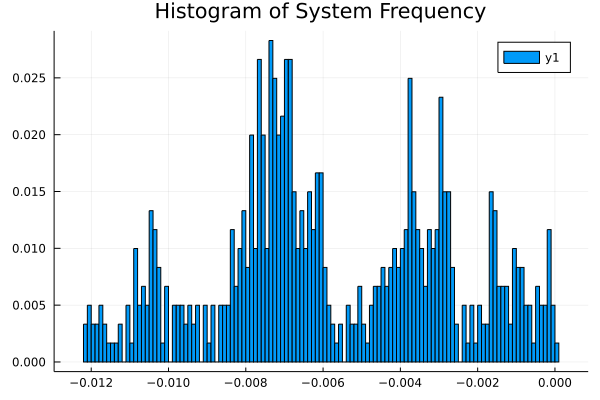

In [8]:
histogram(avgfreq,title="Histogram of System Frequency",normalize=:probability,bins=120)

In [9]:
avgpower=[mean(sol[3n+1:end,i]) for i in 1:tlength]
var(avgpower)

0.0025923195267606247

In [10]:
#Theoretical variance in average power
(tp*σ^2/15)/2

0.004166666666666667